# IVF-PQ Benchmark on real embeddings

Basic approach suggested by f***book guys

Three studies here, all on `embeds.npy`:

1. **Pure IVF baseline** — no compression, `nprobe` sweep
2. **IVF-PQ** — `nlist × M × nbits × nprobe`
3. **IVF-OPQ-PQ** — with a learned rotation before PQ

## 1. Setup

In [4]:
import sys, time
from pathlib import Path

# Find project root robustly (walk up until indexing/ found).
ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "indexing" / "__init__.py").exists():
    ROOT = ROOT.parent
if not (ROOT / "indexing" / "__init__.py").exists():
    raise RuntimeError(f"Not found indexing/ above {Path.cwd()}")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "indexing"))
print(f"ROOT = {ROOT}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

EMBEDS_PATH = ROOT / "data" / "embeds.npy"
N_QUERIES = 300
TOPK = 10

print(f"faiss {faiss.__version__}")


ROOT = /Users/tomatocoder/Desktop/local-wiki-rag
faiss 1.14.3


## 2. Load corpus + queries + ground truth

Loading npy directly (not through `NumpyFileSource`) so the notebook
isn't sensitive to the state of the `indexing/` package imports.


In [5]:

raw = np.load(EMBEDS_PATH, mmap_mode="r")
raw = np.asarray(raw[:], dtype=np.float32)
print(f"real embeddings   : {EMBEDS_PATH}  N={raw.shape[0]:,}  dim={raw.shape[1]}")

corpus = raw
corpus = corpus.astype(np.float32)
N, DIM = corpus.shape

rng = np.random.default_rng(123)
qry_idx = rng.choice(N, size=N_QUERIES, replace=False)
queries = corpus[qry_idx].copy()

# Ground truth: brute-force top-K on the un-quantized corpus.
gt_idx = faiss.IndexFlatIP(DIM); gt_idx.add(corpus)
_, gt = gt_idx.search(queries, TOPK)
print(f"ground truth ready: {gt.shape}  (top-{TOPK})")


real embeddings   : /Users/tomatocoder/Desktop/local-wiki-rag/data/embeds.npy  N=500,000  dim=256
ground truth ready: (300, 10)  (top-10)


## 3. Reusable benchmark harness

In [6]:
def eval_index(idx, queries, gt, topk=TOPK):
    _ = idx.search(queries[:1], topk)  # warmup
    t = time.perf_counter()
    _, labels = idx.search(queries, topk)
    lat_ms = (time.perf_counter() - t) / len(queries) * 1000
    hits = sum(len(set(labels[i].tolist()) & set(gt[i].tolist()))
               for i in range(len(labels)))
    return hits / (len(labels) * topk), lat_ms


def sweep(idx, name, family, param_name, param_values, setter, extra):
    rows = []
    for pv in param_values:
        setter(idx, pv)
        r, lat = eval_index(idx, queries, gt)
        rows.append({"method": name, "family": family,
                     "config": f"{param_name}={pv}",
                     "recall@10": r, "latency_ms": lat, **extra})
        print(f"  {name} {param_name}={pv}: recall={r:.3f}  lat={lat:.3f} ms")
    return rows


all_results = []


## 4. Brute-force ceiling

In [7]:
idx_flat = faiss.IndexFlatIP(DIM)
idx_flat.add(corpus)
r, lat = eval_index(idx_flat, queries, gt)
all_results.append({"method": "flat", "family": "flat", "config": "exact",
                     "recall@10": r, "latency_ms": lat,
                     "memory_bytes_per_vec": DIM * 4, "build_s": 0.0})
print(f"flat (baseline)  recall={r:.3f}  lat={lat:.3f} ms  mem={DIM*4} B/vec")


flat (baseline)  recall=1.000  lat=3.637 ms  mem=1024 B/vec


## 5. Pure IVF sweep

Baseline for compression comparison — no quantization, only spatial
partitioning.


In [19]:
nlist = 1024
quantizer = faiss.IndexFlatIP(DIM)
idx_ivf = faiss.IndexIVFFlat(quantizer, DIM, nlist, faiss.METRIC_INNER_PRODUCT)
t = time.perf_counter()
idx_ivf.train(corpus); idx_ivf.add(corpus)
build_s = time.perf_counter() - t
print(f"IVF(nlist={nlist}) built in {build_s:.2f}s")

rows = sweep(idx_ivf, f"ivf_flat_nlist{nlist}", "ivf_flat",
             "nprobe", [1, 4, 8, 16, 32, 64, 128, 512],
             lambda i, v: setattr(i, "nprobe", v),
             extra={"memory_bytes_per_vec": DIM * 4, "build_s": round(build_s, 2)})
all_results += rows


IVF(nlist=1024) built in 2.19s
  ivf_flat_nlist1024 nprobe=1: recall=0.011  lat=0.008 ms
  ivf_flat_nlist1024 nprobe=4: recall=0.040  lat=0.021 ms
  ivf_flat_nlist1024 nprobe=8: recall=0.062  lat=0.039 ms
  ivf_flat_nlist1024 nprobe=16: recall=0.113  lat=0.074 ms
  ivf_flat_nlist1024 nprobe=32: recall=0.173  lat=0.130 ms
  ivf_flat_nlist1024 nprobe=64: recall=0.262  lat=0.254 ms
  ivf_flat_nlist1024 nprobe=128: recall=0.387  lat=0.521 ms
  ivf_flat_nlist1024 nprobe=512: recall=0.853  lat=1.928 ms


## 6. IVF-PQ sweep — the flagship

Grid: `nlist ∈ {512}` × `M ∈ {16, 32, 64, 128}` × `nbits ∈ {8}` × `nprobe ∈ {4, 16, 64}`.

Memory per vector = `M × nbits / 8` bytes. So M=32 → 32 B/vec, 32×
compression vs the fp32 baseline (1024 B → 32 B).


In [21]:
for M in [ 64, 128]:
    if DIM % M != 0:
        continue
    nbits = 8
    quantizer = faiss.IndexFlatIP(DIM)
    idx = faiss.IndexIVFPQ(quantizer, DIM, nlist, M, nbits, faiss.METRIC_INNER_PRODUCT)

    t = time.perf_counter()
    idx.train(corpus); idx.add(corpus)
    build_s = time.perf_counter() - t
    print(f"IVF-PQ nlist={nlist}, M={M}, nbits={nbits}  built in {build_s:.2f}s")

    rows = sweep(idx, f"ivfpq_M{M}nb{nbits}", "ivf_pq",
                 "nprobe", [1, 4, 16, 64, 128, 512],
                 lambda i, v: setattr(i, "nprobe", v),
                 extra={"memory_bytes_per_vec": M * nbits // 8,
                        "build_s": round(build_s, 2), "M": M, "nbits": nbits})
    all_results += rows


IVF-PQ nlist=1024, M=64, nbits=8  built in 6.39s
  ivfpq_M64nb8 nprobe=1: recall=0.010  lat=0.009 ms
  ivfpq_M64nb8 nprobe=4: recall=0.035  lat=0.014 ms
  ivfpq_M64nb8 nprobe=16: recall=0.091  lat=0.032 ms
  ivfpq_M64nb8 nprobe=64: recall=0.161  lat=0.093 ms
  ivfpq_M64nb8 nprobe=128: recall=0.196  lat=0.166 ms
  ivfpq_M64nb8 nprobe=512: recall=0.196  lat=0.691 ms
IVF-PQ nlist=1024, M=128, nbits=8  built in 9.28s
  ivfpq_M128nb8 nprobe=1: recall=0.011  lat=0.012 ms
  ivfpq_M128nb8 nprobe=4: recall=0.039  lat=0.025 ms
  ivfpq_M128nb8 nprobe=16: recall=0.101  lat=0.068 ms
  ivfpq_M128nb8 nprobe=64: recall=0.208  lat=0.215 ms
  ivfpq_M128nb8 nprobe=128: recall=0.289  lat=0.463 ms
  ivfpq_M128nb8 nprobe=512: recall=0.349  lat=1.726 ms


## 7. IVF-OPQ-PQ with learned rotation

OPQ (Optimized Product Quantization, Ge et al. 2013) prepends a rotation
matrix that decorrelates dimensions so PQ subvectors carry balanced
information


In [17]:
for M in [32, 64, 128]:
    if DIM % M != 0:
        continue
    nbits = 8
    opq = faiss.OPQMatrix(DIM, M)
    quantizer = faiss.IndexFlatIP(DIM)
    ivfpq = faiss.IndexIVFPQ(quantizer, DIM, nlist, M, nbits, faiss.METRIC_INNER_PRODUCT)
    idx = faiss.IndexPreTransform(opq, ivfpq)

    t = time.perf_counter()
    idx.train(corpus); idx.add(corpus)
    build_s = time.perf_counter() - t
    print(f"IVF-OPQ-PQ nlist={nlist}, M={M}  built in {build_s:.2f}s")

    # The nprobe setter must reach through to the wrapped IVFPQ.
    rows = sweep(idx, f"ivfopqpq_M{M}nb{nbits}", "ivf_opq_pq",
                 "nprobe", [1, 4, 16, 64],
                 lambda i, v: setattr(faiss.downcast_index(i.index), "nprobe", v),
                 extra={"memory_bytes_per_vec": M * nbits // 8,
                        "build_s": round(build_s, 2), "M": M, "nbits": nbits})
    all_results += rows


IVF-OPQ-PQ nlist=128, M=32  built in 34.97s
  ivfopqpq_M32nb8 nprobe=1: recall=0.063  lat=0.014 ms
  ivfopqpq_M32nb8 nprobe=4: recall=0.127  lat=0.031 ms
  ivfopqpq_M32nb8 nprobe=16: recall=0.262  lat=0.103 ms
  ivfopqpq_M32nb8 nprobe=64: recall=0.583  lat=0.337 ms
IVF-OPQ-PQ nlist=128, M=64  built in 58.19s
  ivfopqpq_M64nb8 nprobe=1: recall=0.070  lat=0.027 ms
  ivfopqpq_M64nb8 nprobe=4: recall=0.146  lat=0.082 ms
  ivfopqpq_M64nb8 nprobe=16: recall=0.303  lat=0.332 ms
  ivfopqpq_M64nb8 nprobe=64: recall=0.646  lat=1.150 ms
IVF-OPQ-PQ nlist=128, M=128  built in 99.53s
  ivfopqpq_M128nb8 nprobe=1: recall=0.071  lat=0.057 ms
  ivfopqpq_M128nb8 nprobe=4: recall=0.158  lat=0.185 ms
  ivfopqpq_M128nb8 nprobe=16: recall=0.333  lat=0.721 ms
  ivfopqpq_M128nb8 nprobe=64: recall=0.747  lat=3.052 ms


## 8. Combined view — recall / memory / latency

In [22]:
df = pd.DataFrame(all_results)
(ROOT / "experiments").mkdir(exist_ok=True)
df.to_csv(ROOT / "experiments" / "ivfpq_benchmark.csv", index=False)
print(f"saved {len(df)} rows to experiments/ivfpq_benchmark.csv")

df.round(4).sort_values(["family", "config"])


saved 101 rows to experiments/ivfpq_benchmark.csv


,method,family,config,recall@10,latency_ms,memory_bytes_per_vec,build_s,M,nbits
0,flat,flat,exact,1.0000,3.6369,1024,0.00,NaN,NaN
1,ivf_flat_nlist512,ivf_flat,nprobe=1,0.0230,0.0182,1024,0.98,NaN,NaN
7,ivf_flat_nlist128,ivf_flat,nprobe=1,0.0757,0.1317,1024,0.46,NaN,NaN
13,ivf_flat_nlist256,ivf_flat,nprobe=1,0.0380,0.0806,1024,0.52,NaN,NaN
19,ivf_flat_nlist64,ivf_flat,nprobe=1,0.0893,0.0955,1024,0.21,NaN,NaN
...,...,...,...,...,...,...,...,...,...
54,ivfpq_M128nb8,ivf_pq,nprobe=64,0.2270,1.7541,128,8.38,128.0,8.0
84,ivfpq_M64nb8,ivf_pq,nprobe=64,0.1610,0.1027,64,6.30,64.0,8.0
88,ivfpq_M128nb8,ivf_pq,nprobe=64,0.2080,0.2301,128,9.82,128.0,8.0
92,ivfpq_M64nb8,ivf_pq,nprobe=64,0.1610,0.0931,64,6.39,64.0,8.0


### Recall vs memory — headline plot

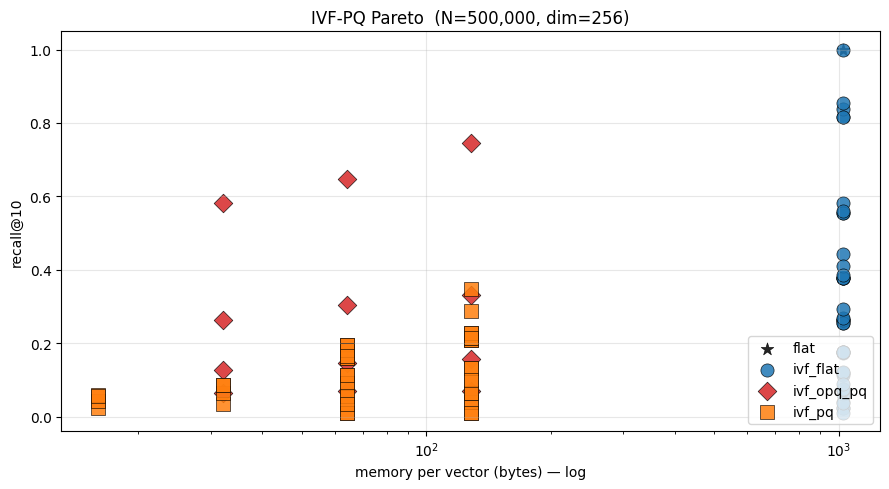

In [23]:
fam_style = {
    "flat":         {"color": "black",       "marker": "*"},
    "ivf_flat":     {"color": "tab:blue",    "marker": "o"},
    "ivf_pq":       {"color": "tab:orange",  "marker": "s"},
    "ivf_opq_pq":   {"color": "tab:red",     "marker": "D"},
}

fig, ax = plt.subplots(figsize=(9, 5))
for fam, sub in df.groupby("family"):
    sub = sub.sort_values("memory_bytes_per_vec")
    s = fam_style[fam]
    ax.scatter(sub["memory_bytes_per_vec"], sub["recall@10"],
               marker=s["marker"], color=s["color"], label=fam,
               s=90, alpha=0.85, edgecolors="black", linewidths=0.5)

ax.set_xscale("log")
ax.set_xlabel("memory per vector (bytes) — log")
ax.set_ylabel("recall@10")
ax.set_title(f"IVF-PQ Pareto  (N={N:,}, dim={DIM})")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Recall vs latency — for the operating-point plot

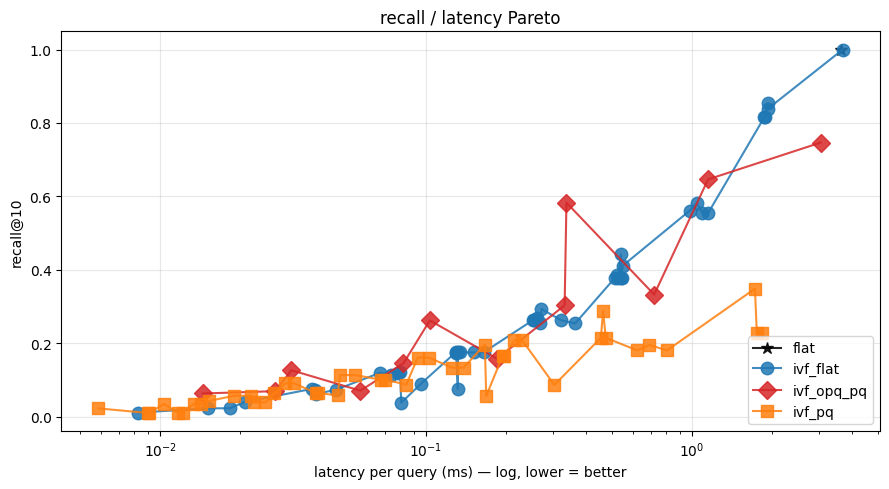

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
for fam, sub in df.groupby("family"):
    sub = sub.sort_values("latency_ms")
    s = fam_style[fam]
    ax.plot(sub["latency_ms"], sub["recall@10"],
            marker=s["marker"], color=s["color"], label=fam,
            linewidth=1.5, markersize=9, alpha=0.85)

ax.set_xscale("log")
ax.set_xlabel("latency per query (ms) — log, lower = better")
ax.set_ylabel("recall@10")
ax.set_title("recall / latency Pareto")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Best config per memory bucket

In [25]:
best_by_mem = (
    df.sort_values("recall@10", ascending=False)
      .groupby("memory_bytes_per_vec")
      .head(1)
      .sort_values("memory_bytes_per_vec")
      [["memory_bytes_per_vec", "method", "config", "recall@10", "latency_ms", "build_s"]]
      .reset_index(drop=True)
      .round(4)
)
best_by_mem


,memory_bytes_per_vec,method,config,recall@10,latency_ms,build_s
0,16,ivfpq_M16nb8,nprobe=16,0.0583,0.0465,5.39
1,32,ivfopqpq_M32nb8,nprobe=64,0.5830,0.3373,34.97
2,64,ivfopqpq_M64nb8,nprobe=64,0.6463,1.1499,58.19
3,128,ivfopqpq_M128nb8,nprobe=64,0.7467,3.0520,99.53
4,1024,flat,exact,1.0000,3.6369,0.00
